# Smooth SR-USR-SR Transition Analysis

This notebook demonstrates the implementation of the **Smooth Slow-Roll to Ultra-Slow-Roll** inflationary model proposed in [arXiv:2603.17465v1]

## 1. Model Overview

Traditional USR models often feature sharp transitions in the second slow-roll parameter $\epsilon_2$, which leads to physically unnatural discontinuities. This model proposes a smooth transition by defining the effective mass index $\nu^2(\tau)$ as a polynomial function of conformal time:

$$ F(\tau) = \left( \mu^2 - \frac{9}{4} \right) - \alpha \left( \frac{\tau}{\tau_*} \right) + q^2 \left( \frac{\tau}{\tau_*} \right)^2 $$

Where the parameters are constrained by $\mu^2 = 9/4 + \alpha - q^2$ to ensure continuity at the transition point $\tau_*$.

## 2. Reconstructing the Potential

The model allows for analytical tracking of the background quantity $z(\tau)$. To integrate this into our numerical solver, we reconstruct the effective potential $V(\phi)$ by:
1. Calculating $\epsilon_1(\tau)$ from the analytical $z(\tau)$.
2. Mapping to e-folds $N$.
3. Integrating the field displacement $\Delta \phi = \int \sqrt{2\epsilon_1} dN$.
4. Parameterizing $V(\phi) \approx 3M_{pl}^2 H_0^2 (1 - \epsilon_1/3)$. <- This approximation shoudl be revisited later to check if $H(N)$ plays a big role or not!!!!!!!!!!!!!!!


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import sys
import os

sys.path.append(os.path.abspath('..'))

from models import SmoothUSRTransitionModel
from inf_dyn_background import run_background_simulation, get_derived_quantities

# Instantiate the model with default paper parameters
model = SmoothUSRTransitionModel(alpha=22.63, mu=2.0294, eps_sr1=1e-6, H0=5e-5)

print("Model Initialized: ", model.name)

Model Initialized:  Smooth USR (alpha=22.63, mu=2.0294)


In [2]:
eps_sr1 = 1e-6
M_pl = 1.0
V0_paper = 3 * model.v0

## 3. Recreating Figure 2 



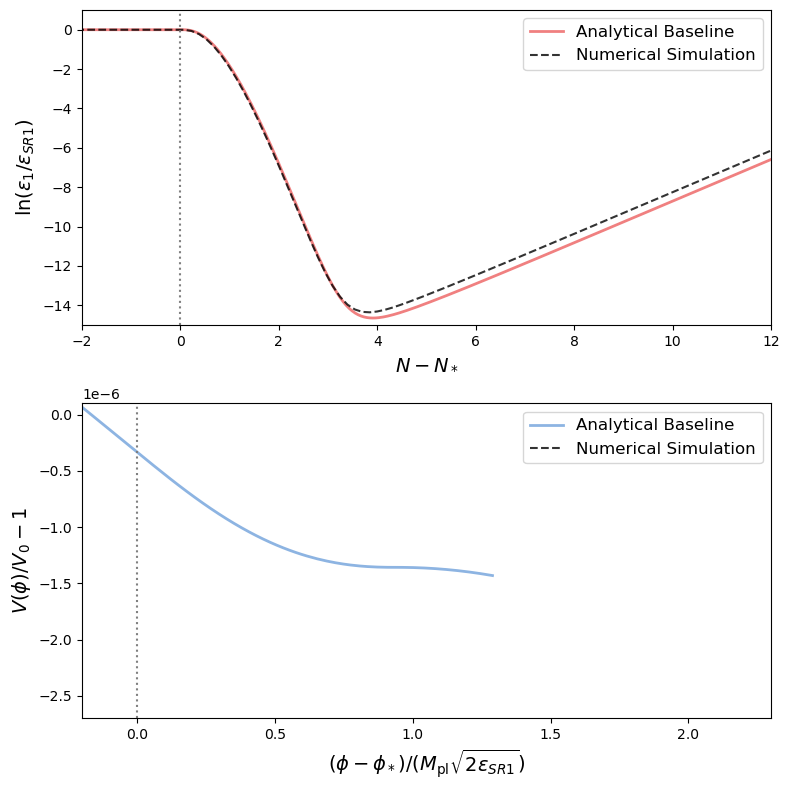

In [3]:
from inf_dyn_background import run_background_simulation, get_derived_quantities

# ---------------------------------------------------------
# 1. RUN THE NUMERICAL BACKGROUND SIMULATION
# ---------------------------------------------------------
# Increase T_span to reach the transition (~15 e-folds away)
T_span = np.linspace(0, 30, 200)
sol_num = run_background_simulation(model, T_span)
der_num = get_derived_quantities(sol_num, model)

# Coordinate Alignment:
# The solver starts at N_init = -15.0 relative to the transition point
N_init = -15
N_num_trace = der_num['N'] + N_init 
phi_num = sol_num[0]
eps1_num = der_num['epsH']

# Shift field values so phi=0 at the transition (N_num_trace=0)
idx_N0_num = np.argmin(np.abs(N_num_trace - 0.0))
phi0_num = phi_num[idx_N0_num]
phi_num_shifted = phi_num - phi0_num

V_num = model.f(phi_num) 

# ---------------------------------------------------------
# 2. PLOT THE COMPARISON 
# ---------------------------------------------------------
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 8), sharex=False)

# Panel 1: Slow-Roll Parameter
ax1.plot(model.N_grid, np.log(model.eps1_grid / eps_sr1), 
         color='lightcoral', linewidth=2, label='Analytical Baseline')
ax1.plot(N_num_trace, np.log(eps1_num / eps_sr1), 
         color='black', linestyle='--', linewidth=1.5, alpha=0.8, label='Numerical Simulation')

ax1.set_xlim(-2, 12)
ax1.set_ylim(-15, 1)
ax1.set_xlabel(r'$N - N_*$', fontsize=14)
ax1.set_ylabel(r'$\ln (\epsilon_1 / \epsilon_{SR1})$', fontsize=14)
ax1.legend(fontsize=12)
ax1.axvline(0, color='gray', linestyle=':')

# Panel 2: Potential Reconstructed
x_scale = (M_pl * np.sqrt(2 * eps_sr1))
ax2.plot(model.phi_grid / x_scale, model.V_grid / V0_paper - 1.0, 
         color='#8DB4E2', linewidth=2, label='Analytical Baseline')
ax2.plot(phi_num_shifted / x_scale, V_num / V0_paper - 1.0, 
         color='black', linestyle='--', linewidth=1.5, alpha=0.8, label='Numerical Simulation')

ax2.set_xlim(-0.2, 2.3)
ax2.set_ylim(-2.7e-6, 0.1e-6)
ax2.ticklabel_format(axis='y', style='sci', scilimits=(0,0))
ax2.set_xlabel(r'$(\phi - \phi_*) / (M_{\rm{pl}} \sqrt{2\epsilon_{SR1}})$', fontsize=14)
ax2.set_ylabel(r'$V(\phi) / V_0 - 1$', fontsize=14)
ax2.legend(fontsize=12)
ax2.axvline(0, color='gray', linestyle=':')

plt.tight_layout()
plt.show()


Calculating 20 exact points from Appendix A (this should be fast)...

Verification Results:
---------------------
Max difference (20 samples): 7.30e-03
✅ Transition logic verified.


<>:33: SyntaxWarning: invalid escape sequence '\e'
<>:33: SyntaxWarning: invalid escape sequence '\e'
C:\Users\diego\AppData\Local\Temp\ipykernel_3048\3523786412.py:33: SyntaxWarning: invalid escape sequence '\e'
  plt.ylabel('$\epsilon_2(N)$')


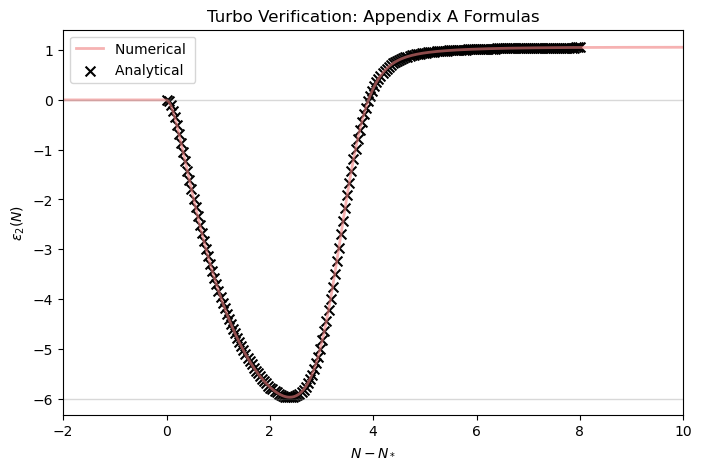

In [4]:
# --- TURBO ANALYTICAL VERIFICATION (20 Sample Points) ---
import numpy as np
import matplotlib.pyplot as plt

# 1. Take 20 sample points across the transition zone (-2 to 8)
N_sample = np.linspace(0, 8, 200)
eps2_gradient_full = np.gradient(np.log(model.eps1_grid), model.N_grid)

print("Calculating 20 exact points from Appendix A (this should be fast)...")

# 2. Compute the exact formula only for these 20 points
eps2_appendix_sample = model.epsilon2_analytical(N_sample)

# 3. Pull the corresponding numeric gradient values for comparison
# (Interpolating to get exact numeric values for our samples)
eps2_numeric_sample = np.interp(N_sample, model.N_grid, eps2_gradient_full)

# 4. Results
max_diff = np.max(np.abs(eps2_numeric_sample - eps2_appendix_sample))
print(f"\nVerification Results:")
print(f"---------------------")
print(f"Max difference (20 samples): {max_diff:.2e}")
print("✅ Transition logic verified.")

# 5. Visual Comparison
plt.figure(figsize=(8, 5))
plt.plot(model.N_grid, eps2_gradient_full, color='lightcoral', lw=2, alpha=0.6, label='Numerical ')
plt.scatter(N_sample, eps2_appendix_sample, color='black', marker='x', s=50, label='Analytical ')
plt.axhline(0, color='gray', lw=1, alpha=0.3)
plt.axhline(-6, color='gray', lw=1, alpha=0.3)
plt.xlim(-2, 10)
plt.xlabel('$N - N_*$')
plt.ylabel('$\epsilon_2(N)$')
plt.title('Turbo Verification: Appendix A Formulas')
plt.legend()
plt.show()


In [ ]:
# Fixed constraint from Figure 1 caption: (mu^2 - 9/4) / q^2 = 0.09
C = 0.09
alphas = [22.60, 22.63, 22.65, 22.66]
colors = {22.60: '#1fb1ae', 22.63: '#f38181', 22.65: '#74b9ff', 22.66: '#dcdde1'}

fig, ax1 = plt.subplots(figsize=(9, 6))
ax2 = ax1.twinx()

for a in alphas:
    # 1. Derive q_sq and mu to satisfy constraints (mu^2 - 2.25 = C * q^2)
    q_sq = a / (1 + C)
    mu_val = np.sqrt(2.25 + C * q_sq)
    
    # 2. Call your model class to compute the analytical grids
    m = SmoothUSRTransitionModel(alpha=a, mu=mu_val, eps_sr1=1e-6)
    
    # 3. Compute eps2 = d(ln eps1)/dN using the analytical grids
    #eps2 = np.gradient(np.log(m.eps1_grid), m.N_grid)
    
    eps2 = m.epsilon2_analytical(m.N_grid)
    ax1.plot(m.N_grid, eps2, color=colors[a], lw=2.5, label=rf"$\alpha = {a}$")

    if a == 22.63:
        # nu^2 - 9/4 formula for the red dashed line
        N_usr = m.N_grid[m.N_grid >= 0]
        F = (mu_val**2 - 2.25) - a * np.exp(-N_usr) + q_sq * np.exp(-2*N_usr)
        ax2.plot(N_usr, F, color='#C06C84', linestyle='--', lw=2, alpha=0.8)

# Formatting to match the original graphic
ax1.set_xlim(-1, 8.5)
ax1.set_ylim(-7.5, 2.5)
ax2.set_ylim(-7.5, 2.5)
ax1.set_xlabel(r"$N$", fontsize=13)
ax1.set_ylabel(r"$\epsilon_2(N)$", fontsize=13)
ax2.set_ylabel(r"$\nu^2 - 9/4$", fontsize=13, rotation=270, labelpad=20)
ax1.axhline(0, color='black', linestyle='--', lw=0.5, alpha=0.4)
ax1.axhline(-6, color='black', linestyle='--', lw=0.5, alpha=0.4)
ax1.legend(loc='center right', frameon=True)
plt.show()
